# Chapter 0b — Prior sensitivity

This notebook performs the targeted prior-robustness check requested after the main framework validation.

It deliberately leaves the scientific model and data-generating process unchanged. The same independently generated datasets are fitted under several reasonable prior specifications so that differences between fits are attributable to the priors rather than to different simulated samples.

The representative setting is the supplied-axis one-sided corruption model with

\[
n=3000,\qquad
p=5,\qquad
\beta_0=-0.8,\qquad
\boldsymbol{\beta}=(1.5,-1.2,0.8,-0.6,0),
\]

\[
R=\{\mathbf{x}:x_5>0.8\},\qquad q=0.35.
\]

The boundary variable is therefore null in the latent-response model. This is a targeted robustness analysis, not a new substantive simulation experiment.

## Prior specifications

Three specifications are compared.

**Baseline** reproduces the dissertation priors:

\[
\beta_0\sim\mathcal N(0,2^2),\qquad
\beta_j\sim\mathcal N(0,1),\qquad
c\sim\mathcal N(0,1),\qquad
q\sim\mathrm{Beta}(2,5).
\]

**Diffuse coefficient/threshold priors** widen the continuous prior scales while leaving the prior on \(q\) unchanged:

\[
\beta_0\sim\mathcal N(0,4^2),\qquad
\beta_j\sim\mathcal N(0,2^2),\qquad
c\sim\mathcal N(0,2^2),\qquad
q\sim\mathrm{Beta}(2,5).
\]

**Uniform corruption-rate prior** leaves the coefficient and threshold priors at baseline but replaces the prior on \(q\) with

\[
q\sim\mathrm{Beta}(1,1).
\]

This separates sensitivity to prior scale from sensitivity to the prior placed directly on the corruption rate.

In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

try:
    from cmdstanpy import CmdStanModel
    STAN_AVAILABLE = True
    print("Stan available — prior sensitivity can be run.")
except ImportError:
    STAN_AVAILABLE = False
    print("cmdstanpy is not installed in this environment.")

SEED = 42

# Representative simulation setting
N = 3000
P = 5
TRUE_BETA0 = -0.8
TRUE_BETA = np.array([1.5, -1.2, 0.8, -0.6, 0.0])
TRUE_C = 0.8
TRUE_Q = 0.35
BOUNDARY_DIM = 4          # Python index: x_5
KAPPA = 5.0

# Targeted paired robustness check requested for prior sensitivity.
# Start with 10 independently generated datasets. If the running-mean
# diagnostics at the end are still materially unstable, increase this
# to 20; the checkpoint will continue from the completed fits.
N_REPS = 10

CHAINS = 4
ITER_WARMUP = 1000
ITER_SAMPLING = 2000
ADAPT_DELTA = 0.95
MAX_TREEDEPTH = 12
PARALLEL_CHAINS = min(CHAINS, os.cpu_count() or CHAINS)

OUTPUT_DIR = Path("high_replication") / "chapter0b_prior_sensitivity"
FIT_DIR = OUTPUT_DIR / "stan_fits"
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = OUTPUT_DIR / "prior_sensitivity_results.csv"

print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"Replicates requested: {N_REPS}")

Stan available — prior sensitivity can be run.
Output directory: /Users/demikramer/Desktop/final_project_folder copy/high_replication/chapter0b_prior_sensitivity
Replicates requested: 10


In [2]:
PRIOR_SPECS = {
    "baseline": {
        "beta0_sd": 2.0,
        "beta_sd": 1.0,
        "c_mean": 0.0,
        "c_sd": 1.0,
        "q_a": 2.0,
        "q_b": 5.0,
    },
    "diffuse": {
        "beta0_sd": 4.0,
        "beta_sd": 2.0,
        "c_mean": 0.0,
        "c_sd": 2.0,
        "q_a": 2.0,
        "q_b": 5.0,
    },
    "q_uniform": {
        "beta0_sd": 2.0,
        "beta_sd": 1.0,
        "c_mean": 0.0,
        "c_sd": 1.0,
        "q_a": 1.0,
        "q_b": 1.0,
    },
}

pd.DataFrame(PRIOR_SPECS).T

,beta0_sd,beta_sd,c_mean,c_sd,q_a,q_b
baseline,2.0,1.0,0.0,1.0,2.0,5.0
diffuse,4.0,2.0,0.0,2.0,2.0,5.0
q_uniform,2.0,1.0,0.0,1.0,1.0,1.0


## Stan model with prior hyperparameters supplied as data

The likelihood is the same one-sided \(1\to0\) marginal likelihood used in Chapter 0. Only the prior hyperparameters are exposed as data so that the same model can be refitted under the three specifications above.

In [3]:
stan_code_prior_sensitivity = r'''
data {
  int<lower=0> n;
  int<lower=0> p;
  matrix[n, p] X;
  array[n] int<lower=0, upper=1> y;
  int<lower=1, upper=p> boundary_dim;
  real kappa;

  real<lower=0> beta0_prior_sd;
  real<lower=0> beta_prior_sd;
  real c_prior_mean;
  real<lower=0> c_prior_sd;
  real<lower=0> q_prior_a;
  real<lower=0> q_prior_b;
}

parameters {
  real beta0;
  vector[p] beta;
  real c;
  real<lower=0, upper=1> q;
}

model {
  beta0 ~ normal(0, beta0_prior_sd);
  beta  ~ normal(0, beta_prior_sd);
  c     ~ normal(c_prior_mean, c_prior_sd);
  q     ~ beta(q_prior_a, q_prior_b);

  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X[, boundary_dim] - c));

    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);
      real log_1p = log1m_inv_logit(eta[i]);
      real log_qr = log(q) + log_r[i];

      if (y[i] == 1) {
        target += log1m_exp(log_qr) + log_p;
      } else {
        target += log_sum_exp(log_1p, log_qr + log_p);
      }
    }
  }
}

generated quantities {
  vector[n] z_prob;
  vector[n] r;
  vector[n] log_lik;

  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X[, boundary_dim] - c));

    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);
      real log_1p = log1m_inv_logit(eta[i]);
      real log_qr = log(q) + log_r[i];

      r[i] = exp(log_r[i]);

      if (y[i] == 1) {
        z_prob[i]  = 0;
        log_lik[i] = log1m_exp(log_qr) + log_p;
      } else {
        real log_corr = log_qr + log_p;
        real log_tot  = log_sum_exp(log_1p, log_corr);
        z_prob[i]  = exp(log_corr - log_tot);
        log_lik[i] = log_tot;
      }
    }
  }
}
'''

STAN_FILE = OUTPUT_DIR / "corruption_model_axis_PRIOR_SENSITIVITY.stan"
STAN_FILE.write_text(stan_code_prior_sensitivity)
print(f"Wrote: {STAN_FILE}")

if STAN_AVAILABLE:
    model_prior = CmdStanModel(stan_file=str(STAN_FILE))
    print("Stan model compiled.")

11:11:35 - cmdstanpy - INFO - compiling stan file /var/folders/hk/s02zbvd931b5x94gx2t9sh940000gn/T/tmp9rvuwsal/tmpjfq6kjvq.stan to exe file /Users/demikramer/Desktop/final_project_folder copy/high_replication/chapter0b_prior_sensitivity/corruption_model_axis_PRIOR_SENSITIVITY


Wrote: high_replication/chapter0b_prior_sensitivity/corruption_model_axis_PRIOR_SENSITIVITY.stan


11:11:40 - cmdstanpy - INFO - compiled model executable: /Users/demikramer/Desktop/final_project_folder copy/high_replication/chapter0b_prior_sensitivity/corruption_model_axis_PRIOR_SENSITIVITY


Stan model compiled.


## Data-generating process

Each replicate is generated once and then reused under every prior specification. This paired design is important: it prevents ordinary between-dataset variation from being mistaken for prior sensitivity.

In [4]:
def logistic_dgp(n, rng, p=P):
    X = rng.normal(0, 1, size=(n, p))
    eta = TRUE_BETA0 + X @ TRUE_BETA
    prob = 1.0 / (1.0 + np.exp(-eta))
    y_true = rng.binomial(1, prob).astype(int)
    return X, y_true


def corrupt_one_sided(y_true, region, q, rng):
    eligible = (y_true == 1) & region
    flips = eligible & (rng.random(len(y_true)) < q)
    y_obs = y_true.copy()
    y_obs[flips] = 0
    return y_obs, flips


def generate_replicate(rep):
    # Separate deterministic streams for the response DGP and corruption.
    data_seed = SEED + 1000 + rep
    corrupt_seed = SEED + 100000 + rep

    rng_data = np.random.default_rng(data_seed)
    rng_corrupt = np.random.default_rng(corrupt_seed)

    X, y_true = logistic_dgp(N, rng_data)
    region = X[:, BOUNDARY_DIM] > TRUE_C
    y_obs, flips = corrupt_one_sided(y_true, region, TRUE_Q, rng_corrupt)

    return {
        "X": X,
        "y_true": y_true,
        "region": region,
        "y_obs": y_obs,
        "flips": flips,
        "data_seed": data_seed,
        "corrupt_seed": corrupt_seed,
    }


# Quick deterministic check
example = generate_replicate(1)
print(
    f"Example replicate: region={example['region'].mean():.3f}, "
    f"eligible={((example['y_true'] == 1) & example['region']).sum()}, "
    f"corruptions={example['flips'].sum()}"
)

Example replicate: region=0.216, eligible=243, corruptions=88


In [5]:
def make_stan_data(dataset, prior):
    return {
        "n": N,
        "p": P,
        "X": dataset["X"].tolist(),
        "y": dataset["y_obs"].tolist(),
        "boundary_dim": BOUNDARY_DIM + 1,  # Stan is 1-indexed
        "kappa": KAPPA,
        "beta0_prior_sd": prior["beta0_sd"],
        "beta_prior_sd": prior["beta_sd"],
        "c_prior_mean": prior["c_mean"],
        "c_prior_sd": prior["c_sd"],
        "q_prior_a": prior["q_a"],
        "q_prior_b": prior["q_b"],
    }


def core_diagnostics(fit):
    summary = fit.summary()

    core_names = (
        ["beta0"]
        + [f"beta[{j}]" for j in range(1, P + 1)]
        + ["c", "q"]
    )
    core = summary.loc[[x for x in core_names if x in summary.index]]

    # CmdStanPy column names vary slightly by version.
    normalized = {
        str(col).lower().replace("_", "").replace("-", ""): col
        for col in core.columns
    }

    rhat_col = None
    for key in ("rhat",):
        if key in normalized:
            rhat_col = normalized[key]
            break

    # Prefer bulk ESS when available. Older CmdStanPy summaries may expose
    # only N_Eff; use it as the effective-sample-size diagnostic fallback.
    ess_col = None
    for key in ("essbulk", "bulkeffsamplesize", "neff"):
        if key in normalized:
            ess_col = normalized[key]
            break

    max_rhat = np.nan
    min_bulk_ess = np.nan

    if rhat_col is not None:
        max_rhat = float(
            np.nanmax(core[rhat_col].to_numpy(dtype=float))
        )

    if ess_col is not None:
        min_bulk_ess = float(
            np.nanmin(core[ess_col].to_numpy(dtype=float))
        )

    method_vars = fit.method_variables()
    divergences = int(
        np.asarray(method_vars.get("divergent__", 0)).sum()
    )
    td = np.asarray(method_vars.get("treedepth__", []))
    treedepth_hits = (
        int((td >= MAX_TREEDEPTH).sum()) if td.size else 0
    )

    diagnostic_pass = (
        np.isfinite(max_rhat)
        and max_rhat <= 1.05
        and np.isfinite(min_bulk_ess)
        and min_bulk_ess >= 100
        and divergences == 0
        and treedepth_hits == 0
    )

    return {
        "max_rhat": max_rhat,
        "min_bulk_ess": min_bulk_ess,
        "divergences": divergences,
        "treedepth_hits": treedepth_hits,
        "diagnostic_pass": bool(diagnostic_pass),
    }


def posterior_metrics(fit, dataset):
    beta0 = fit.stan_variable("beta0")
    beta = fit.stan_variable("beta")
    c_draws = fit.stan_variable("c")
    q_draws = fit.stan_variable("q")
    z_mean = fit.stan_variable("z_prob").mean(axis=0)

    beta_mean = beta.mean(axis=0)
    c_lo, c_hi = np.percentile(c_draws, [2.5, 97.5])
    q_lo, q_hi = np.percentile(q_draws, [2.5, 97.5])

    neg = dataset["y_obs"] == 0
    k = int(dataset["flips"].sum())

    auc = roc_auc_score(dataset["flips"][neg], z_mean[neg])

    if k > 0:
        top = np.argsort(-z_mean[neg])[:k]
        precision_k = float(dataset["flips"][neg][top].mean())
    else:
        precision_k = np.nan

    out = {
        "region_share": float(dataset["region"].mean()),
        "eligible_positives": int(((dataset["y_true"] == 1) & dataset["region"]).sum()),
        "corruptions": int(dataset["flips"].sum()),
        "effective_flip_rate": float(dataset["flips"].mean()),

        "beta0_mean": float(beta0.mean()),
        "beta0_abs_error": float(abs(beta0.mean() - TRUE_BETA0)),
        "beta_rmse": float(np.sqrt(np.mean((beta_mean - TRUE_BETA) ** 2))),

        "c_mean": float(c_draws.mean()),
        "c_abs_error": float(abs(c_draws.mean() - TRUE_C)),
        "c_sd": float(c_draws.std(ddof=1)),
        "c_ci_width": float(c_hi - c_lo),
        "c_coverage": bool(c_lo <= TRUE_C <= c_hi),

        "q_mean": float(q_draws.mean()),
        "q_abs_error": float(abs(q_draws.mean() - TRUE_Q)),
        "q_sd": float(q_draws.std(ddof=1)),
        "q_ci_width": float(q_hi - q_lo),
        "q_coverage": bool(q_lo <= TRUE_Q <= q_hi),

        "localisation_auc": float(auc),
        "precision_at_k": precision_k,
    }
    out.update(core_diagnostics(fit))
    return out

## Run the paired sensitivity analysis

The checkpoint CSV is updated after every completed fit. If execution is interrupted, rerun this cell: completed replicate/prior pairs will be skipped.

With \(10\) datasets and \(3\) prior specifications this is \(30\) Stan fits. If more replication is later required, increase `N_REPS` to 20 and rerun; the first 10 replicates will be retained and only the additional fits will be run.

In [6]:
if not STAN_AVAILABLE:
    raise RuntimeError("cmdstanpy/Stan is required to run this notebook.")

if RESULTS_CSV.exists():
    results = pd.read_csv(RESULTS_CSV)
    print(f"Loaded checkpoint with {len(results)} completed fits.")
else:
    results = pd.DataFrame()

completed = set()
if len(results):
    completed = set(zip(results["rep"].astype(int), results["prior"].astype(str)))

rows = results.to_dict("records") if len(results) else []

for rep in range(1, N_REPS + 1):
    dataset = generate_replicate(rep)

    print(
        f"\nDataset {rep}/{N_REPS}: "
        f"region={dataset['region'].mean():.3f}, "
        f"corruptions={dataset['flips'].sum()}"
    )

    for prior_idx, (prior_name, prior_spec) in enumerate(PRIOR_SPECS.items()):
        key = (rep, prior_name)
        if key in completed:
            print(f"  {prior_name:<10} — checkpoint found, skipping")
            continue

        print(f"  {prior_name:<10} — fitting")

        fit_output = FIT_DIR / f"rep_{rep:02d}" / prior_name
        fit_output.mkdir(parents=True, exist_ok=True)

        fit = model_prior.sample(
            data=make_stan_data(dataset, prior_spec),
            chains=CHAINS,
            parallel_chains=PARALLEL_CHAINS,
            iter_warmup=ITER_WARMUP,
            iter_sampling=ITER_SAMPLING,
            seed=SEED + 200000 + rep * 100 + prior_idx,
            adapt_delta=ADAPT_DELTA,
            max_treedepth=MAX_TREEDEPTH,
            output_dir=str(fit_output),
            show_progress=False,
        )

        row = {
            "rep": rep,
            "prior": prior_name,
            "data_seed": dataset["data_seed"],
            "corrupt_seed": dataset["corrupt_seed"],
        }
        row.update(posterior_metrics(fit, dataset))
        rows.append(row)

        results = pd.DataFrame(rows).sort_values(["rep", "prior"]).reset_index(drop=True)
        results.to_csv(RESULTS_CSV, index=False)

        print(
            f"    c={row['c_mean']:.3f}, q={row['q_mean']:.3f}, "
            f"beta RMSE={row['beta_rmse']:.3f}, "
            f"AUC={row['localisation_auc']:.3f}, "
            f"diag_pass={row['diagnostic_pass']}"
        )

print(f"\nFinished. Checkpoint saved to: {RESULTS_CSV}")


Dataset 1/10: region=0.216, corruptions=88
  baseline   — fitting


11:11:40 - cmdstanpy - INFO - CmdStan start processing
11:11:40 - cmdstanpy - INFO - Chain [1] start processing
11:11:40 - cmdstanpy - INFO - Chain [2] start processing
11:11:40 - cmdstanpy - INFO - Chain [3] start processing
11:11:40 - cmdstanpy - INFO - Chain [4] start processing
11:11:54 - cmdstanpy - INFO - Chain [2] done processing
11:11:54 - cmdstanpy - INFO - Chain [1] done processing
11:11:55 - cmdstanpy - INFO - Chain [3] done processing
11:11:55 - cmdstanpy - INFO - Chain [4] done processing
11:12:42 - cmdstanpy - INFO - CmdStan start processing
11:12:42 - cmdstanpy - INFO - Chain [1] start processing
11:12:42 - cmdstanpy - INFO - Chain [2] start processing
11:12:42 - cmdstanpy - INFO - Chain [3] start processing
11:12:42 - cmdstanpy - INFO - Chain [4] start processing


    c=0.911, q=0.414, beta RMSE=0.042, AUC=0.963, diag_pass=True
  diffuse    — fitting


11:12:55 - cmdstanpy - INFO - Chain [3] done processing
11:12:56 - cmdstanpy - INFO - Chain [2] done processing
11:12:57 - cmdstanpy - INFO - Chain [4] done processing
11:12:58 - cmdstanpy - INFO - Chain [1] done processing
11:13:44 - cmdstanpy - INFO - CmdStan start processing
11:13:44 - cmdstanpy - INFO - Chain [1] start processing
11:13:44 - cmdstanpy - INFO - Chain [2] start processing
11:13:44 - cmdstanpy - INFO - Chain [3] start processing
11:13:44 - cmdstanpy - INFO - Chain [4] start processing


    c=0.915, q=0.416, beta RMSE=0.041, AUC=0.963, diag_pass=True
  q_uniform  — fitting


...

    c=0.877, q=0.441, beta RMSE=0.063, AUC=0.975, diag_pass=True
  diffuse    — fitting


11:42:33 - cmdstanpy - INFO - Chain [2] done processing
11:42:33 - cmdstanpy - INFO - Chain [4] done processing
11:42:34 - cmdstanpy - INFO - Chain [1] done processing
11:42:36 - cmdstanpy - INFO - Chain [3] done processing
11:43:22 - cmdstanpy - INFO - CmdStan start processing
11:43:22 - cmdstanpy - INFO - Chain [1] start processing
11:43:22 - cmdstanpy - INFO - Chain [2] start processing
11:43:22 - cmdstanpy - INFO - Chain [3] start processing
11:43:22 - cmdstanpy - INFO - Chain [4] start processing


    c=0.880, q=0.442, beta RMSE=0.063, AUC=0.975, diag_pass=True
  q_uniform  — fitting


11:43:43 - cmdstanpy - INFO - Chain [4] done processing
11:43:44 - cmdstanpy - INFO - Chain [2] done processing
11:43:44 - cmdstanpy - INFO - Chain [3] done processing
11:43:45 - cmdstanpy - INFO - Chain [1] done processing


    c=0.884, q=0.455, beta RMSE=0.066, AUC=0.975, diag_pass=True

Finished. Checkpoint saved to: high_replication/chapter0b_prior_sensitivity/prior_sensitivity_results.csv


## Aggregate results

The main comparison uses between-dataset means and standard deviations. Standard deviations here describe variation across independently generated datasets; they are not posterior standard deviations or standard errors of the aggregate mean.

In [7]:
results = pd.read_csv(RESULTS_CSV)

metrics = [
    "beta0_abs_error",
    "beta_rmse",
    "c_abs_error",
    "c_sd",
    "c_ci_width",
    "c_coverage",
    "q_abs_error",
    "q_sd",
    "q_ci_width",
    "q_coverage",
    "localisation_auc",
    "precision_at_k",
    "diagnostic_pass",
]

summary_rows = []
for prior_name, g in results.groupby("prior"):
    row = {"prior": prior_name, "n_fits": len(g)}
    for metric in metrics:
        vals = pd.to_numeric(g[metric], errors="coerce")
        row[f"{metric}_mean"] = vals.mean()
        row[f"{metric}_sd"] = vals.std(ddof=1)
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).set_index("prior")
summary

,n_fits,beta0_abs_error_mean,beta0_abs_error_sd,beta_rmse_mean,beta_rmse_sd,c_abs_error_mean,c_abs_error_sd,c_sd_mean,c_sd_sd,c_ci_width_mean,...,q_ci_width_mean,q_ci_width_sd,q_coverage_mean,q_coverage_sd,localisation_auc_mean,localisation_auc_sd,precision_at_k_mean,precision_at_k_sd,diagnostic_pass_mean,diagnostic_pass_sd
prior,,,,,,,,,,,,,,,,,,,,,
baseline,10,0.053546,0.042984,0.064444,0.018379,0.075769,0.040965,0.098253,0.019931,0.387360,...,0.217801,0.017291,1.0,0.000000,0.966762,0.006917,0.579293,0.056006,1.0,0.0
diffuse,10,0.053676,0.042914,0.066297,0.018613,0.077348,0.043267,0.097338,0.018980,0.384462,...,0.216668,0.016195,0.9,0.316228,0.966804,0.006867,0.580335,0.054442,1.0,0.0
q_uniform,10,0.054848,0.042251,0.065479,0.018844,0.080107,0.042185,0.096975,0.020882,0.381083,...,0.223943,0.019959,0.9,0.316228,0.966906,0.006883,0.581272,0.055032,1.0,0.0


## Paired comparison with the baseline prior

Because every prior is fitted to the same datasets, paired differences provide the cleanest robustness comparison. Values near zero indicate that changing the prior has little effect on that estimand for the representative simulation setting.

In [8]:
paired_metrics = [
    "beta_rmse",
    "c_abs_error",
    "q_abs_error",
    "localisation_auc",
    "precision_at_k",
    "c_mean",
    "q_mean",
]

paired_rows = []

for metric in paired_metrics:
    wide = results.pivot(index="rep", columns="prior", values=metric)
    if "baseline" not in wide.columns:
        continue

    for prior_name in [p for p in PRIOR_SPECS if p != "baseline"]:
        if prior_name not in wide.columns:
            continue

        d = (wide[prior_name] - wide["baseline"]).dropna()
        paired_rows.append({
            "metric": metric,
            "comparison": f"{prior_name} - baseline",
            "mean_paired_difference": d.mean(),
            "sd_paired_difference": d.std(ddof=1),
            "max_abs_paired_difference": np.abs(d).max(),
            "n_pairs": len(d),
        })

paired_summary = pd.DataFrame(paired_rows)
paired_summary

,metric,comparison,mean_paired_difference,sd_paired_difference,max_abs_paired_difference,n_pairs
0,beta_rmse,diffuse - baseline,0.001854,0.002448,0.005213,10
1,beta_rmse,q_uniform - baseline,0.001035,0.001584,0.002696,10
2,c_abs_error,diffuse - baseline,0.001579,0.005802,0.013376,10
3,c_abs_error,q_uniform - baseline,0.004338,0.006169,0.009273,10
4,q_abs_error,diffuse - baseline,0.001041,0.002703,0.004574,10
5,q_abs_error,q_uniform - baseline,0.011200,0.006541,0.016034,10
6,localisation_auc,diffuse - baseline,0.000041,0.000087,0.000282,10
7,localisation_auc,q_uniform - baseline,0.000144,0.000082,0.000310,10
8,precision_at_k,diffuse - baseline,0.001042,0.003294,0.010417,10
9,precision_at_k,q_uniform - baseline,0.001979,0.007462,0.013158,10


## Between-dataset variability plots

Each point is the mean across datasets and each error bar is \(\pm 1\) between-dataset standard deviation. These are deliberately not labelled as confidence intervals.

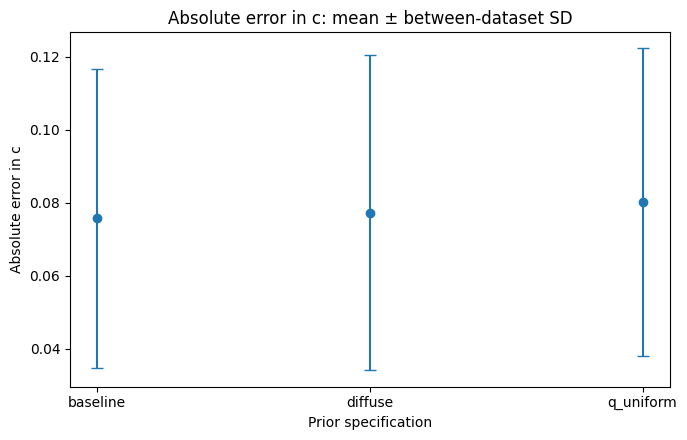

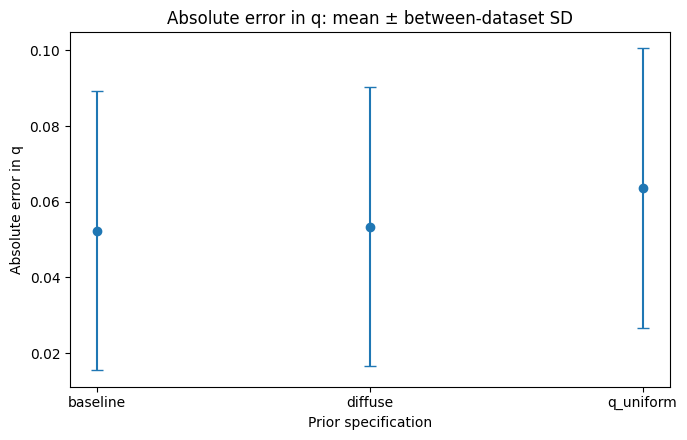

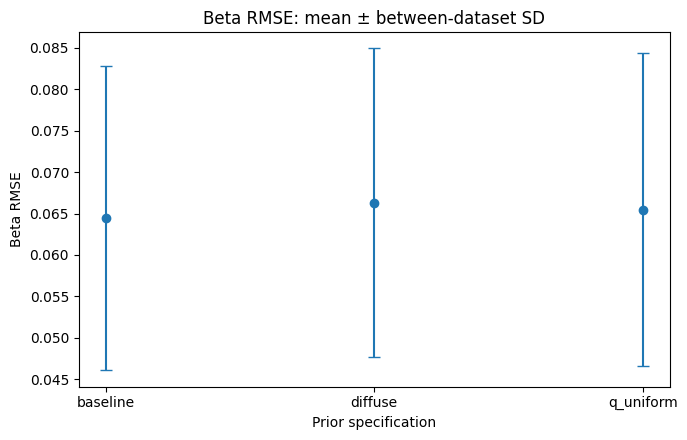

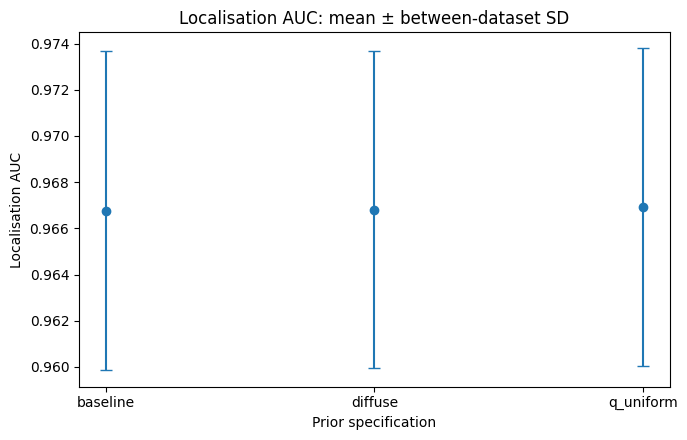

In [9]:
def mean_sd_plot(metric, ylabel, filename):
    order = [p for p in PRIOR_SPECS if p in results["prior"].unique()]
    means = [results.loc[results["prior"] == p, metric].mean() for p in order]
    sds = [results.loc[results["prior"] == p, metric].std(ddof=1) for p in order]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.errorbar(order, means, yerr=sds, fmt="o", capsize=4)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Prior specification")
    ax.set_title(f"{ylabel}: mean ± between-dataset SD")
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


mean_sd_plot("c_abs_error", "Absolute error in c", "prior_sensitivity_c_error.png")
mean_sd_plot("q_abs_error", "Absolute error in q", "prior_sensitivity_q_error.png")
mean_sd_plot("beta_rmse", "Beta RMSE", "prior_sensitivity_beta_rmse.png")
mean_sd_plot("localisation_auc", "Localisation AUC", "prior_sensitivity_auc.png")

## Running-mean stability check

These plots show whether the estimated average sensitivity has stabilised as the number of paired datasets increases. If the curves are still moving materially at 10 replicates, increase `N_REPS` to 20 and continue from the checkpoint.

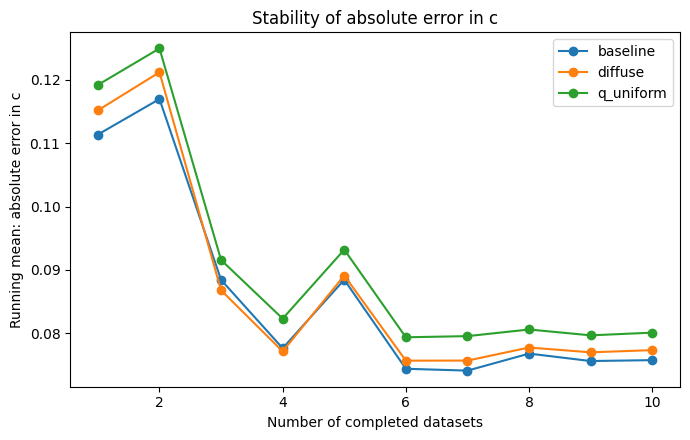

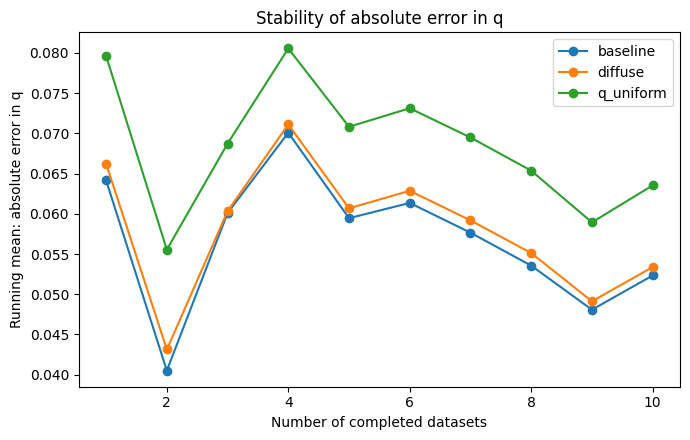

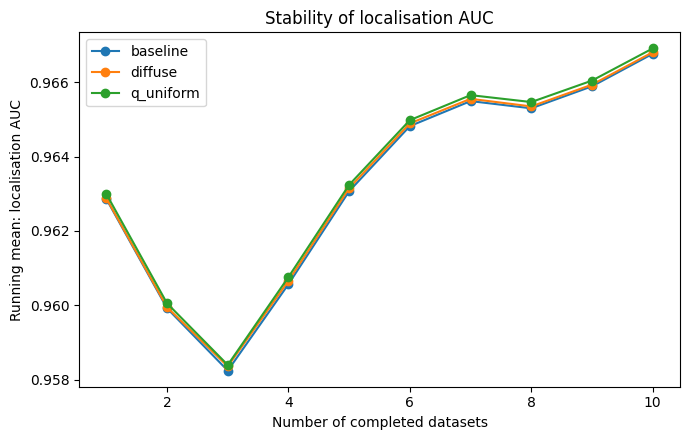

In [10]:
def running_mean_plot(metric, ylabel, filename):
    fig, ax = plt.subplots(figsize=(7, 4.5))

    for prior_name in PRIOR_SPECS:
        g = (
            results.loc[results["prior"] == prior_name, ["rep", metric]]
            .sort_values("rep")
            .dropna()
        )
        if len(g) == 0:
            continue
        running = g[metric].expanding().mean()
        ax.plot(g["rep"], running, marker="o", label=prior_name)

    ax.set_xlabel("Number of completed datasets")
    ax.set_ylabel(f"Running mean: {ylabel}")
    ax.set_title(f"Stability of {ylabel}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


running_mean_plot("c_abs_error", "absolute error in c", "running_mean_c_error.png")
running_mean_plot("q_abs_error", "absolute error in q", "running_mean_q_error.png")
running_mean_plot("localisation_auc", "localisation AUC", "running_mean_auc.png")

## Diagnostic failures

Prior sensitivity should not be judged from fits that fail the prespecified MCMC checks. The table below identifies any such fits.

In [11]:
failed = results.loc[
    ~results["diagnostic_pass"].astype(bool),
    [
        "rep",
        "prior",
        "max_rhat",
        "min_bulk_ess",
        "divergences",
        "treedepth_hits",
    ],
]

if len(failed):
    display(failed)
else:
    print("All completed prior-sensitivity fits satisfy the prespecified diagnostic criteria.")

All completed prior-sensitivity fits satisfy the prespecified diagnostic criteria.


## Manuscript update after the run

A concise Methods description can be added to the Priors subsection:

> To assess sensitivity to the prior specification, a targeted robustness analysis was conducted under a representative axis-supplied simulation setting. The same independently generated datasets were fitted under the baseline priors and under alternative specifications that separately widened the coefficient and threshold priors and replaced the \(\mathrm{Beta}(2,5)\) prior on the corruption probability with a uniform \(\mathrm{Beta}(1,1)\) prior. Comparisons focused on recovery of \(c\), \(q\) and \(\boldsymbol{\beta}\), observation-level localisation and posterior diagnostics. Pairing the prior specifications within the same simulated datasets isolates changes due to the prior from between-dataset simulation variability.

Do **not** write the Results conclusion until this notebook has finished. Report what the paired results actually show. If the alternatives give similar recovery/localisation, describe the main conclusions as insensitive to these reasonable prior changes in this representative setting. If \(c\) or \(q\) changes materially, report that sensitivity rather than calling the model globally robust.

## Output files

All outputs are isolated under

`high_replication/chapter0b_prior_sensitivity/`

so this notebook does not overwrite the existing Chapter 0 figures or Stan files.

The principal machine-readable output is:

`prior_sensitivity_results.csv`

and every Stan fit is kept in its own replicate/prior directory for later inspection if required.

## Final interpretation rule

This is a **targeted prior-sensitivity robustness check**, not a new main
simulation experiment. The same independently generated datasets are paired
across the three prior specifications so that differences are attributable to
the prior choice rather than dataset-to-dataset variation.

Start with the 10 paired datasets specified above. Inspect the running-mean
plots for \(c\) error, \(q\) error and localisation AUC. If the summaries are
still moving materially at replicate 10, set `N_REPS = 20` and rerun; the
checkpoint will skip completed fits and continue from replicate 11.